In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Chargement du fichier (chemin correct)
df = pd.read_csv('data/processed/credit_data_clean.csv')
print(f"✅ Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
df.head()

✅ Dataset chargé : 30000 lignes, 24 colonnes


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


✅ Dataset chargé : 30000 lignes, 24 colonnes

=== TAUX DE DÉFAUT ===
Taux global : 22.12%


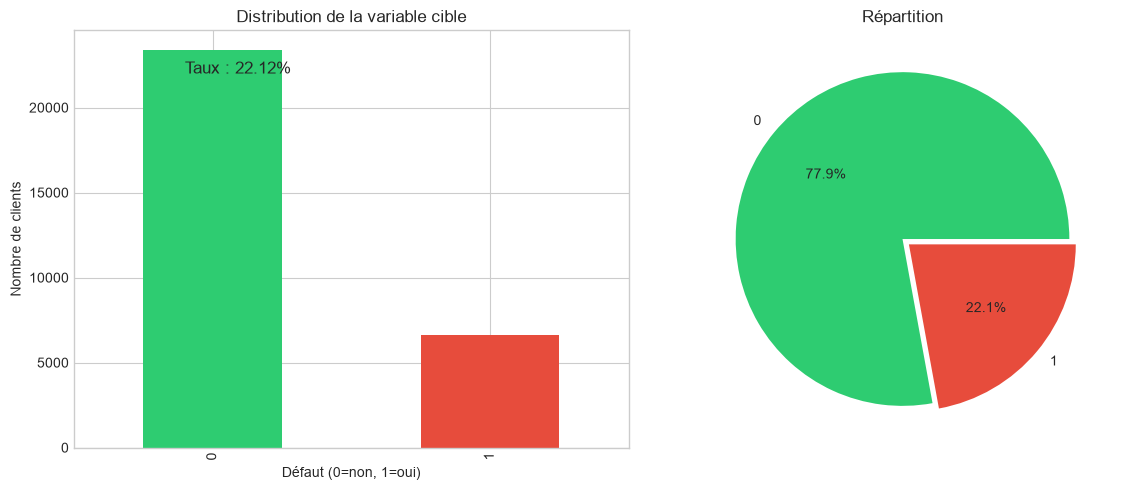

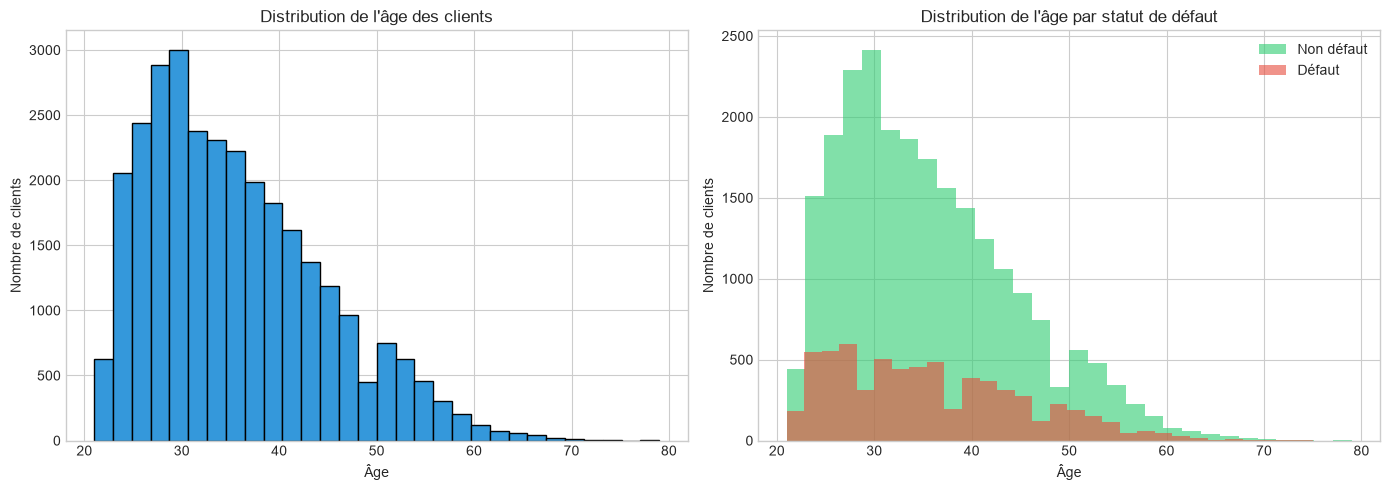


=== TAUX DE DÉFAUT PAR TRANCHE D'ÂGE ===
age_group
18-24    0.271881
55-64    0.268293
65+      0.254545
45-54    0.239310
35-44    0.218563
25-34    0.202982
Name: default, dtype: float64


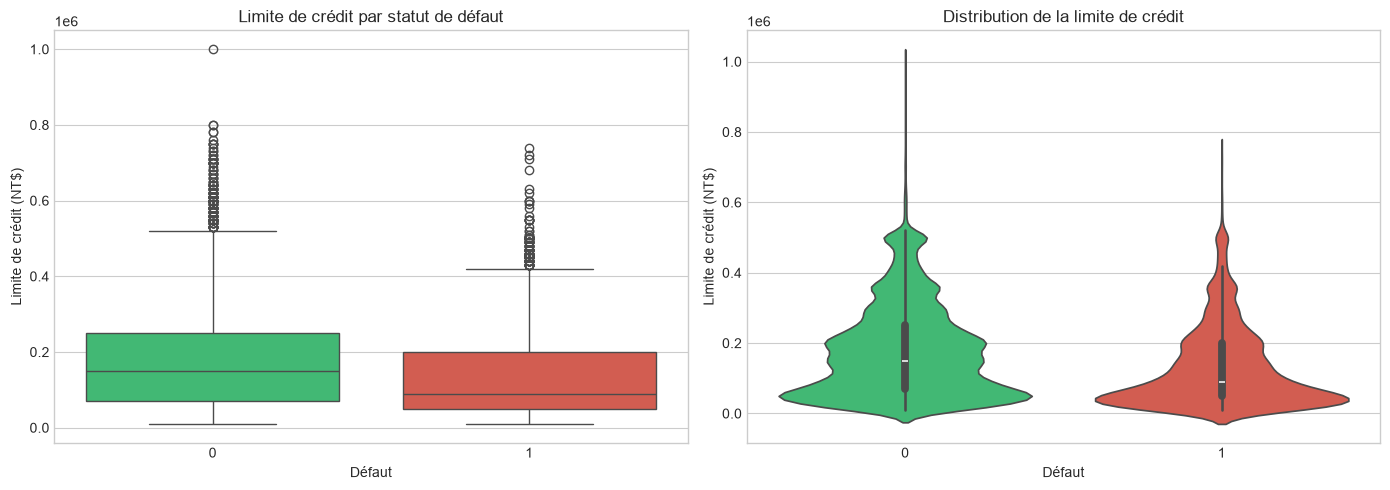


=== STATISTIQUES LIMITE DE CRÉDIT PAR DÉFAUT ===
           count           mean            std      min      25%       50%  \
default                                                                      
0        23364.0  178099.726074  131628.359660  10000.0  70000.0  150000.0   
1         6636.0  130109.656420  115378.540571  10000.0  50000.0   90000.0   

              75%        max  
default                       
0        250000.0  1000000.0  
1        200000.0   740000.0  


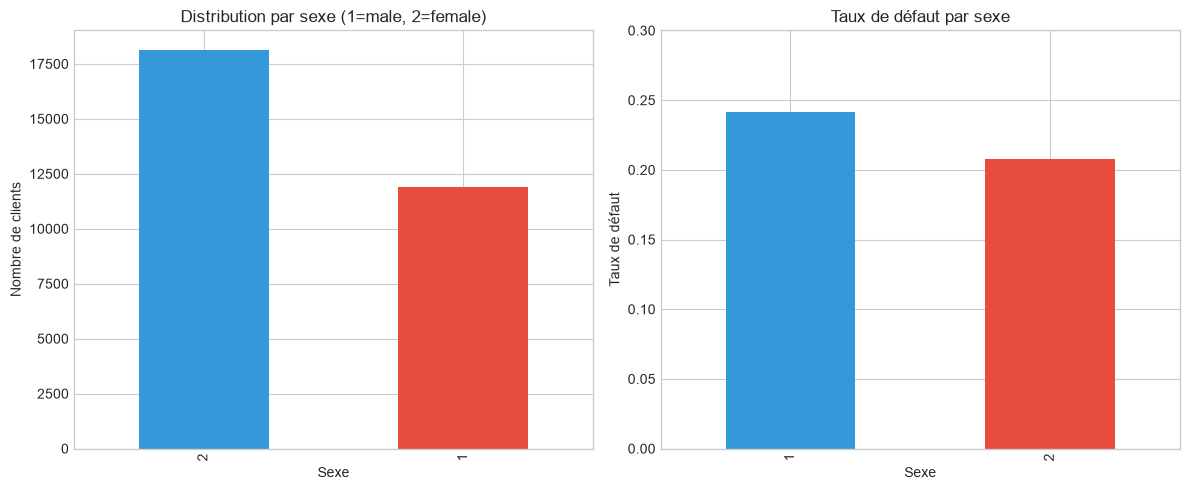


=== TAUX DE DÉFAUT PAR SEXE ===
SEX
1    0.241672
2    0.207763
Name: default, dtype: float64

=== TAUX DE DÉFAUT PAR NIVEAU D'ÉDUCATION ===
EDUCATION
3    0.251576
2    0.237349
1    0.192348
6    0.156863
5    0.064286
4    0.056911
0    0.000000
Name: default, dtype: float64


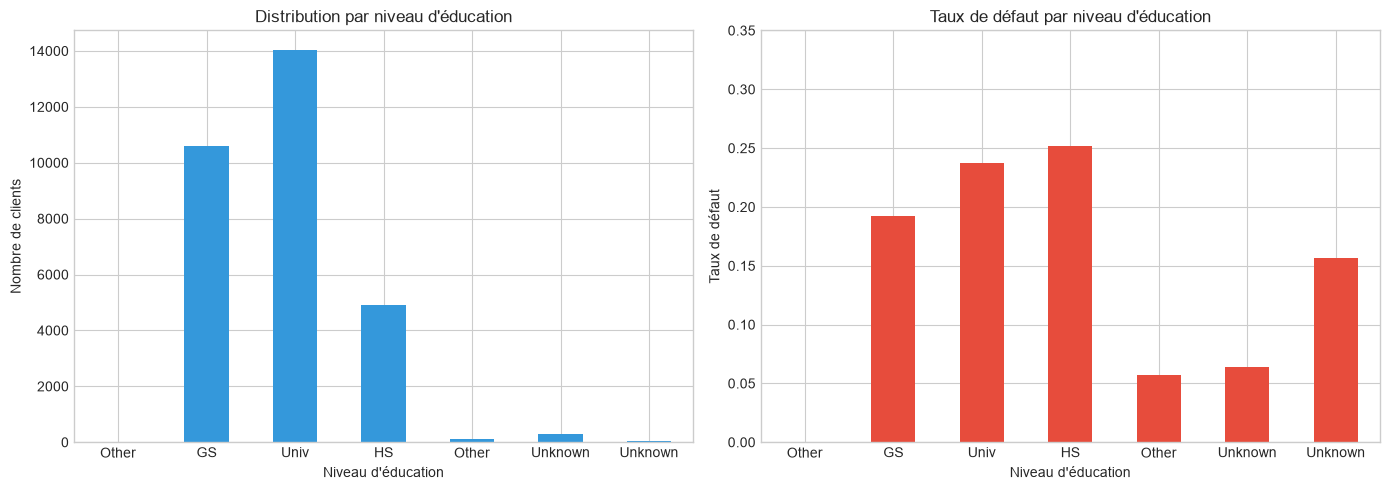

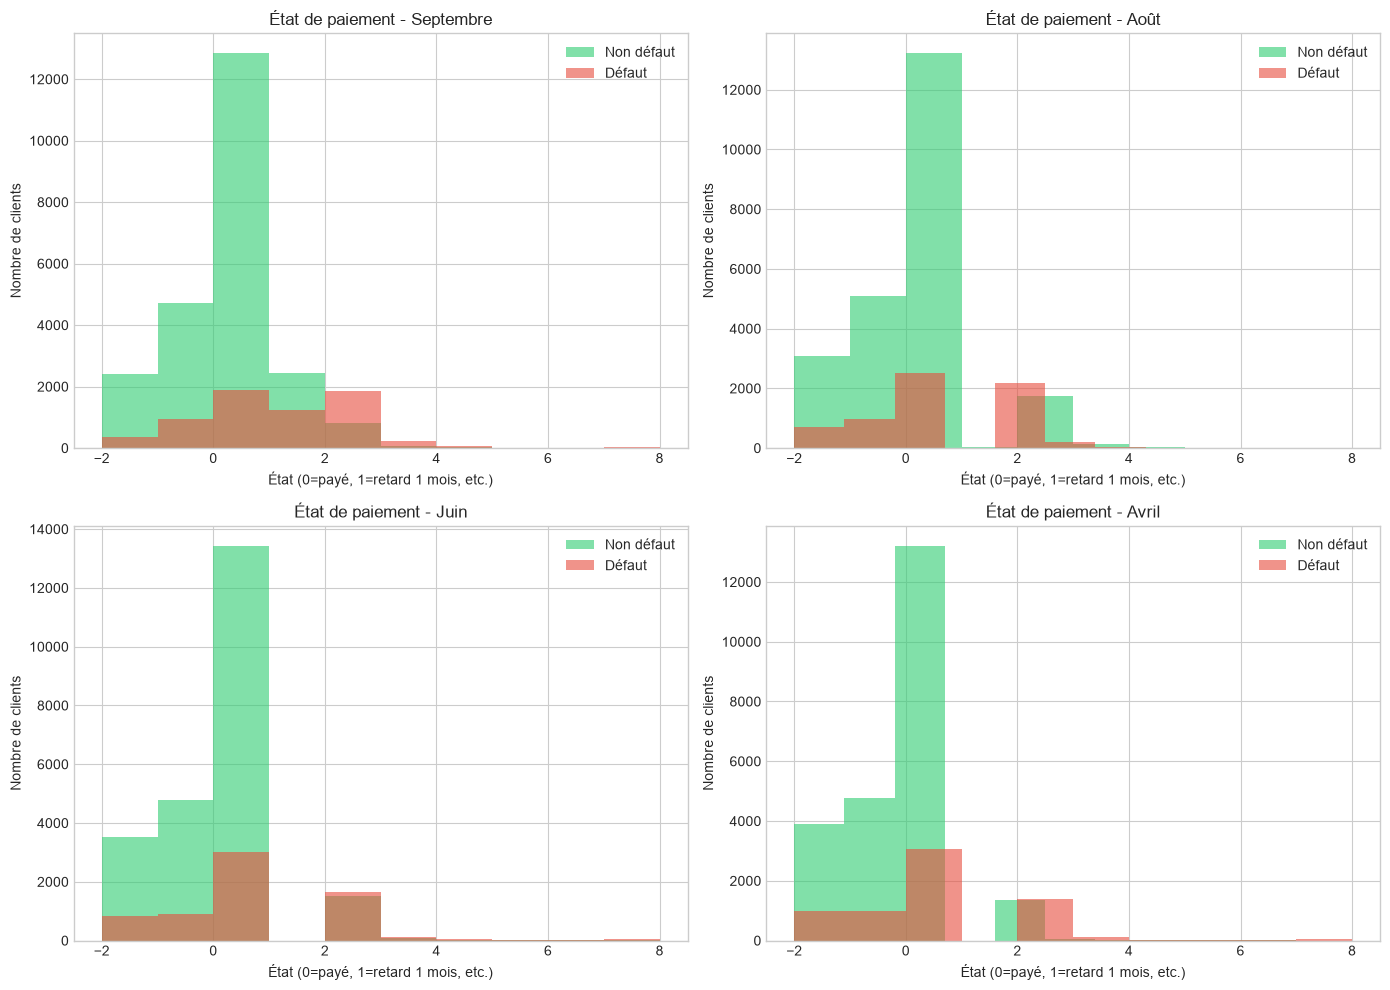


=== MOYENNE DES RETARDS PAR MOIS ===
PAY_0: -0.02
PAY_2: -0.13
PAY_4: -0.22
PAY_6: -0.29

=== TAUX DE DÉFAUT PAR RETARD (PAY_0) ===
PAY_0
 7    0.777778
 3    0.757764
 2    0.691414
 4    0.684211
 8    0.578947
 6    0.545455
 5    0.500000
 1    0.339479
-1    0.167781
-2    0.132294
 0    0.128113
Name: default, dtype: float64


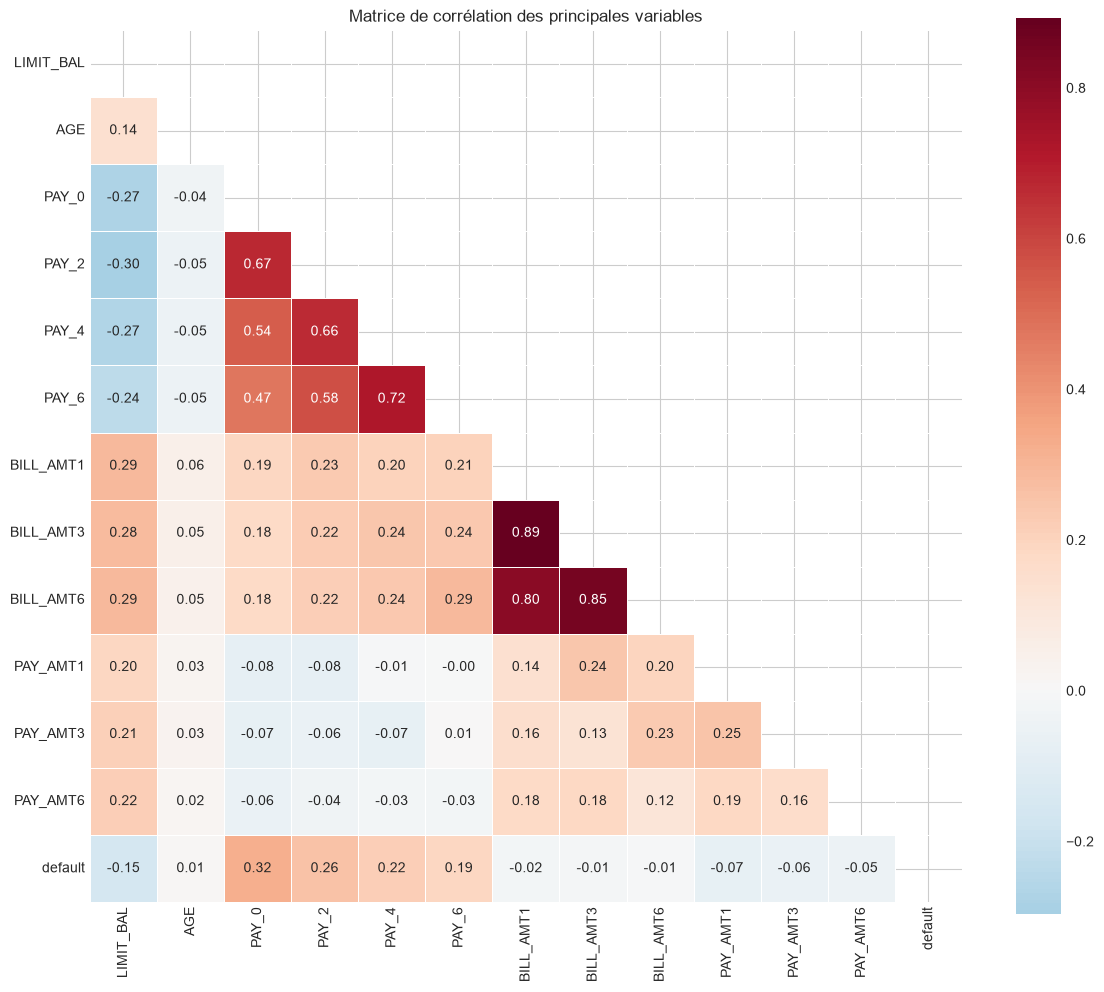


=== CORRÉLATION AVEC LA CIBLE ===
default      1.000000
PAY_0        0.324794
PAY_2        0.263551
PAY_4        0.216614
PAY_6        0.186866
AGE          0.013890
BILL_AMT6   -0.005372
BILL_AMT3   -0.014076
BILL_AMT1   -0.019644
PAY_AMT6    -0.053183
PAY_AMT3    -0.056250
PAY_AMT1    -0.072929
LIMIT_BAL   -0.153520
Name: default, dtype: float64


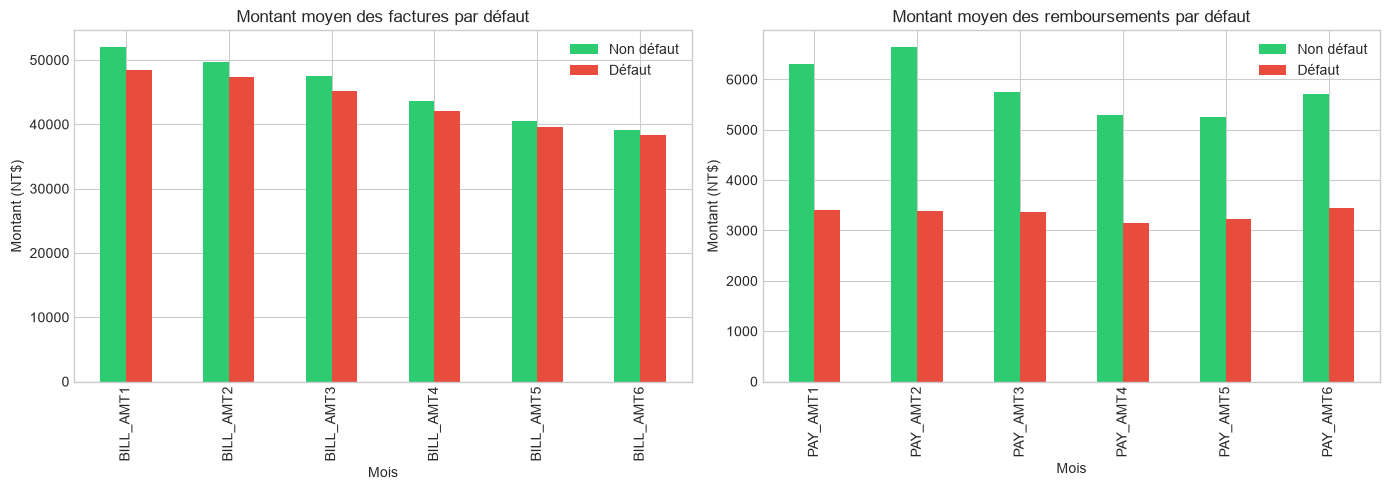


=== INSIGHTS CLÉS ===
1. Taux de défaut global : 22.12%
2. Âge moyen des clients : 35.49 ans
3. Limite de crédit moyenne : 167,484 NT$
4. Sexe le plus représenté : Femme
5. Niveau d'éducation le plus fréquent : 2
6. Mois avec le plus de retards : PAY_0 (moyenne=-0.02)

✅ Analyse EDA terminée !


In [3]:
# %% [markdown]
# # 02 - Exploratory Data Analysis (EDA)
# ## Projet : AI Credit Risk Prediction Platform
# ## Dataset : UCI Default of Credit Card Clients

# %% [markdown]
# ### 1. Import des librairies

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)

# %%
# Chargement des données nettoyées
df = pd.read_csv('data/processed/credit_data_clean.csv')
print(f"✅ Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
df.head()

# %% [markdown]
# ### 2. Analyse de la variable cible

# %%
print("\n=== TAUX DE DÉFAUT ===")
print(f"Taux global : {df['default'].mean()*100:.2f}%")

# %%
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#2ecc71', '#e74c3c']

# Bar chart
df['default'].value_counts().plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Distribution de la variable cible')
axes[0].set_xlabel('Défaut (0=non, 1=oui)')
axes[0].set_ylabel('Nombre de clients')
axes[0].text(-0.1, 22000, f'Taux : {df["default"].mean()*100:.2f}%', fontsize=12)

# Pie chart
df['default'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                   colors=colors, explode=[0, 0.05])
axes[1].set_title('Répartition')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../data/processed/target_distribution.png', dpi=150)
plt.show()

# %% [markdown]
# ### 3. Analyse par âge

# %%
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution globale
df['AGE'].hist(bins=30, ax=axes[0], color='#3498db', edgecolor='black')
axes[0].set_title('Distribution de l\'âge des clients')
axes[0].set_xlabel('Âge')
axes[0].set_ylabel('Nombre de clients')

# Par défaut
for default in [0, 1]:
    label = 'Non défaut' if default == 0 else 'Défaut'
    color = '#2ecc71' if default == 0 else '#e74c3c'
    df[df['default'] == default]['AGE'].hist(bins=30, alpha=0.6, 
                                              label=label, color=color, ax=axes[1])
axes[1].set_title('Distribution de l\'âge par statut de défaut')
axes[1].set_xlabel('Âge')
axes[1].set_ylabel('Nombre de clients')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/age_distribution.png', dpi=150)
plt.show()

# %%
# Taux de défaut par tranche d'âge
age_bins = [18, 25, 35, 45, 55, 65, 80]
age_labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df['age_group'] = pd.cut(df['AGE'], bins=age_bins, labels=age_labels, right=False)

print("\n=== TAUX DE DÉFAUT PAR TRANCHE D'ÂGE ===")
print(df.groupby('age_group')['default'].mean().sort_values(ascending=False))

# %% [markdown]
# ### 4. Analyse par limite de crédit

# %%
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(x='default', y='LIMIT_BAL', data=df, ax=axes[0], palette=colors)
axes[0].set_title('Limite de crédit par statut de défaut')
axes[0].set_xlabel('Défaut')
axes[0].set_ylabel('Limite de crédit (NT$)')

# Violin plot
sns.violinplot(x='default', y='LIMIT_BAL', data=df, ax=axes[1], palette=colors)
axes[1].set_title('Distribution de la limite de crédit')
axes[1].set_xlabel('Défaut')
axes[1].set_ylabel('Limite de crédit (NT$)')

plt.tight_layout()
plt.savefig('../data/processed/limit_balance.png', dpi=150)
plt.show()

# %%
print("\n=== STATISTIQUES LIMITE DE CRÉDIT PAR DÉFAUT ===")
print(df.groupby('default')['LIMIT_BAL'].describe())

# %% [markdown]
# ### 5. Analyse par sexe

# %%
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Distribution des sexes
df['SEX'].value_counts().plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'])
axes[0].set_title('Distribution par sexe (1=male, 2=female)')
axes[0].set_xlabel('Sexe')
axes[0].set_ylabel('Nombre de clients')

# Taux de défaut par sexe
df.groupby('SEX')['default'].mean().plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c'])
axes[1].set_title('Taux de défaut par sexe')
axes[1].set_xlabel('Sexe')
axes[1].set_ylabel('Taux de défaut')
axes[1].set_ylim(0, 0.3)

plt.tight_layout()
plt.savefig('../data/processed/sex_analysis.png', dpi=150)
plt.show()

# %%
print("\n=== TAUX DE DÉFAUT PAR SEXE ===")
print(df.groupby('SEX')['default'].mean())

# %% [markdown]
# ### 6. Analyse par niveau d'éducation

# %%
print("\n=== TAUX DE DÉFAUT PAR NIVEAU D'ÉDUCATION ===")
print(df.groupby('EDUCATION')['default'].mean().sort_values(ascending=False))

# %%
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Définir les labels selon les valeurs
education_labels = {
    0: 'Other', 1: 'GS', 2: 'Univ', 
    3: 'HS', 4: 'Other', 5: 'Unknown', 6: 'Unknown'
}

# Distribution
df['EDUCATION'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#3498db')
axes[0].set_title('Distribution par niveau d\'éducation')
axes[0].set_xlabel('Niveau d\'éducation')
axes[0].set_ylabel('Nombre de clients')
# Définir les labels automatiquement
axes[0].set_xticklabels([education_labels.get(x, str(x)) for x in sorted(df['EDUCATION'].unique())], rotation=0)

# Taux de défaut
df.groupby('EDUCATION')['default'].mean().plot(kind='bar', ax=axes[1], color='#e74c3c')
axes[1].set_title('Taux de défaut par niveau d\'éducation')
axes[1].set_xlabel('Niveau d\'éducation')
axes[1].set_ylabel('Taux de défaut')
axes[1].set_ylim(0, 0.35)
axes[1].set_xticklabels([education_labels.get(x, str(x)) for x in sorted(df['EDUCATION'].unique())], rotation=0)

plt.tight_layout()
plt.savefig('../data/processed/education_analysis.png', dpi=150)
plt.show()

# %% [markdown]
# ### 7. Historique de paiement

# %%
# Colonnes de paiement
pay_cols = ['PAY_0', 'PAY_2', 'PAY_4', 'PAY_6']
pay_labels = ['Septembre', 'Août', 'Juin', 'Avril']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(pay_cols):
    for default in [0, 1]:
        label = 'Non défaut' if default == 0 else 'Défaut'
        color = '#2ecc71' if default == 0 else '#e74c3c'
        df[df['default'] == default][col].hist(bins=10, alpha=0.6, 
                                                label=label, color=color, ax=axes[idx])
    axes[idx].set_title(f'État de paiement - {pay_labels[idx]}')
    axes[idx].set_xlabel('État (0=payé, 1=retard 1 mois, etc.)')
    axes[idx].set_ylabel('Nombre de clients')
    axes[idx].legend()

plt.tight_layout()
plt.savefig('../data/processed/payment_history.png', dpi=150)
plt.show()

# %%
# Analyse des retards
print("\n=== MOYENNE DES RETARDS PAR MOIS ===")
for col in pay_cols:
    print(f"{col}: {df[col].mean():.2f}")

print("\n=== TAUX DE DÉFAUT PAR RETARD (PAY_0) ===")
print(df.groupby('PAY_0')['default'].mean().sort_values(ascending=False))

# %% [markdown]
# ### 8. Matrice de corrélation

# %%
# Variables principales
cols = ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_4', 'PAY_6', 
        'BILL_AMT1', 'BILL_AMT3', 'BILL_AMT6', 
        'PAY_AMT1', 'PAY_AMT3', 'PAY_AMT6', 'default']

corr = df[cols].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu_r', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Matrice de corrélation des principales variables')
plt.tight_layout()
plt.savefig('../data/processed/correlation_matrix.png', dpi=150)
plt.show()

# %%
# Corrélation avec la cible
print("\n=== CORRÉLATION AVEC LA CIBLE ===")
corr_target = df[cols].corr()['default'].sort_values(ascending=False)
print(corr_target)

# %% [markdown]
# ### 9. Analyse des factures et remboursements

# %%
# Montant des factures
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
pay_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Moyenne des factures par défaut
df.groupby('default')[bill_cols].mean().T.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Montant moyen des factures par défaut')
axes[0].set_xlabel('Mois')
axes[0].set_ylabel('Montant (NT$)')
axes[0].legend(['Non défaut', 'Défaut'])

# Moyenne des remboursements par défaut
df.groupby('default')[pay_cols].mean().T.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Montant moyen des remboursements par défaut')
axes[1].set_xlabel('Mois')
axes[1].set_ylabel('Montant (NT$)')
axes[1].legend(['Non défaut', 'Défaut'])

plt.tight_layout()
plt.savefig('../data/processed/bills_payments_analysis.png', dpi=150)
plt.show()

# %% [markdown]
# ### 10. Résumé des insights

# %%
print("\n=== INSIGHTS CLÉS ===")
print(f"1. Taux de défaut global : {df['default'].mean()*100:.2f}%")
print(f"2. Âge moyen des clients : {df['AGE'].mean():.2f} ans")
print(f"3. Limite de crédit moyenne : {df['LIMIT_BAL'].mean():,.0f} NT$")
print(f"4. Sexe le plus représenté : {'Femme' if df['SEX'].mean() > 1.5 else 'Homme'}")
print(f"5. Niveau d'éducation le plus fréquent : {df['EDUCATION'].mode()[0]}")
print(f"6. Mois avec le plus de retards : PAY_0 (moyenne={df['PAY_0'].mean():.2f})")

print("\n✅ Analyse EDA terminée !")